# Data Cleaning

In [163]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../../data/raw/bank-full.csv", sep=";")

print(df.head())

   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  


In [184]:
# check missing values
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [164]:
# check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


### All columns have correct data types and no missing values, so the dataset is structurally fine and ready for analysis.

In [165]:
# summary statistics
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


### Everything looks structurally fine with realistic ranges.

In [167]:
# check duplicate rows
print(df.duplicated().sum())

0


### The dataset has no duplicate values.

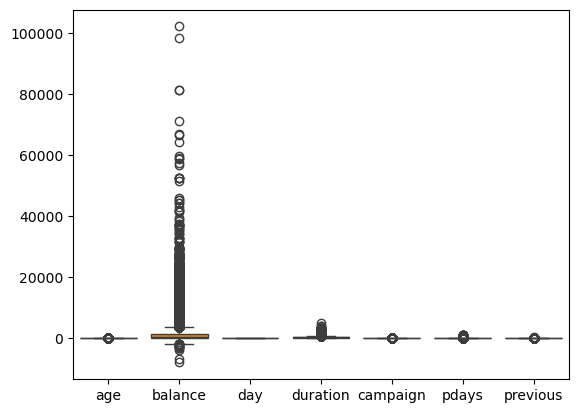

In [168]:
# select numeric colunms
num_cols = ['age','balance','day','duration','campaign','pdays','previous']

# create a boxplot for each column
sns.boxplot(data=df[num_cols])
plt.show()

### The dataset shows extreme but domain-valid variation in balance reflecting real-world wealth inequality, while all other variables are clean with no significant outliers.

In [169]:
# select categorical column
cat_cols = ['job','marital','education','default','housing','loan','contact','month','poutcome','y']

# unique values
for col in cat_cols:
    print(f"Unique values in '{col}': {df[col].unique()}")

Unique values in 'job': ['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']
Unique values in 'marital': ['married' 'single' 'divorced']
Unique values in 'education': ['tertiary' 'secondary' 'unknown' 'primary']
Unique values in 'default': ['no' 'yes']
Unique values in 'housing': ['yes' 'no']
Unique values in 'loan': ['no' 'yes']
Unique values in 'contact': ['unknown' 'cellular' 'telephone']
Unique values in 'month': ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']
Unique values in 'poutcome': ['unknown' 'failure' 'other' 'success']
Unique values in 'y': ['no' 'yes']


In [170]:
# standardize column, remove dot for consistency
df['job'] = df['job'].str.replace('.', '', regex=False)

In [171]:
# define the correct order
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
df['month'] = pd.Categorical(df['month'], categories=month_order,ordered=True)

# EDA (Campaign Strategy)

### 1. How does the subscription rate vary across months?

/var/folders/m9/3qw5qv8x7bdb20d_n3wnbqpm0000gn/T/ipykernel_27025/2298484526.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  month_success = eda_df.groupby('month')['only_yes'].mean().mul(100).reset_index()
/var/folders/m9/3qw5qv8x7bdb20d_n3wnbqpm0000gn/T/ipykernel_27025/2298484526.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='month', y='only_yes', data=month_success, palette=month_success['color'].tolist())


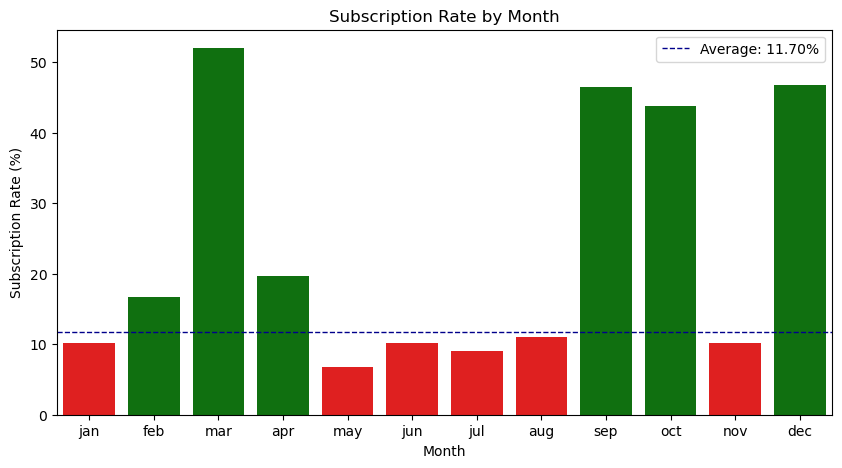

In [173]:
eda_df = df.copy()
eda_df['only_yes'] = (eda_df['y'] == 'yes').astype(int)
month_success = eda_df.groupby('month')['only_yes'].mean().mul(100).reset_index()
overall_avg = eda_df['only_yes'].mean() * 100

plt.figure(figsize=(10,5))
month_success['color'] = month_success['only_yes'].apply(lambda x: 'green' if x >= overall_avg else 'red')
sns.barplot(x='month', y='only_yes', data=month_success, palette=month_success['color'].tolist())
plt.axhline(overall_avg, color='darkblue', linestyle='--', linewidth=1, label=f'Average: {overall_avg:.2f}%')
plt.title('Subscription Rate by Month')
plt.ylabel('Subscription Rate (%)')
plt.xlabel('Month')
plt.legend()
plt.show()

### Answer: Yes, subscription rates are higher in specific months. March stands out with the highest subscription rate (over 50%). September, October, and December also have subscription rates well above the average line.

### 2. How does call duration relate to subscription? 

/var/folders/m9/3qw5qv8x7bdb20d_n3wnbqpm0000gn/T/ipykernel_27025/2966207095.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  duration_success = eda_df.groupby('duration_bin')['only_yes'].mean().mul(100).reset_index()
/var/folders/m9/3qw5qv8x7bdb20d_n3wnbqpm0000gn/T/ipykernel_27025/2966207095.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='duration_bin', y='only_yes', data=duration_success, palette=duration_success['color'].tolist())


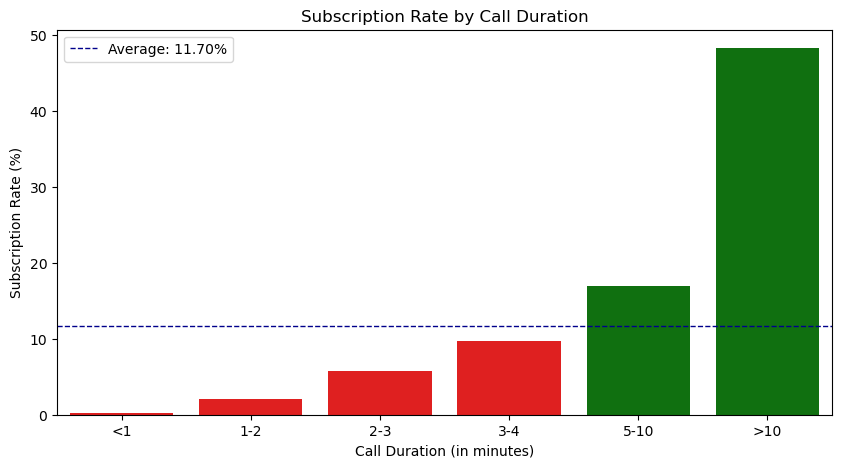

In [174]:
# define bins (in minutes)
bins = [0, 1, 2, 3, 4, 10, eda_df['duration'].max()+1]
labels = ['<1','1-2','2-3','3-4','5-10','>10']
# create bins
eda_df['duration_bin'] = pd.cut(eda_df['duration']/60, bins=bins, labels=labels, right=False)

duration_success = eda_df.groupby('duration_bin')['only_yes'].mean().mul(100).reset_index()

plt.figure(figsize=(10,5))
duration_success['color'] = duration_success['only_yes'].apply(lambda x: 'green' if x >= overall_avg else 'red')
sns.barplot(x='duration_bin', y='only_yes', data=duration_success, palette=duration_success['color'].tolist())
plt.axhline(overall_avg, color='darkblue', linestyle='--', linewidth=1, label=f'Average: {overall_avg:.2f}%')
plt.ylabel('Subscription Rate (%)')
plt.xlabel('Call Duration (in minutes)')
plt.title('Subscription Rate by Call Duration')
plt.legend()
plt.show()

### Answer: Yes, longer calls lead to more subscriptions. Spending more time talking helps convince customers, while very short calls rarely work. To get better results, calls should last at least 5 minutes.

### 3. Does subscription probability decrease after too many calls?


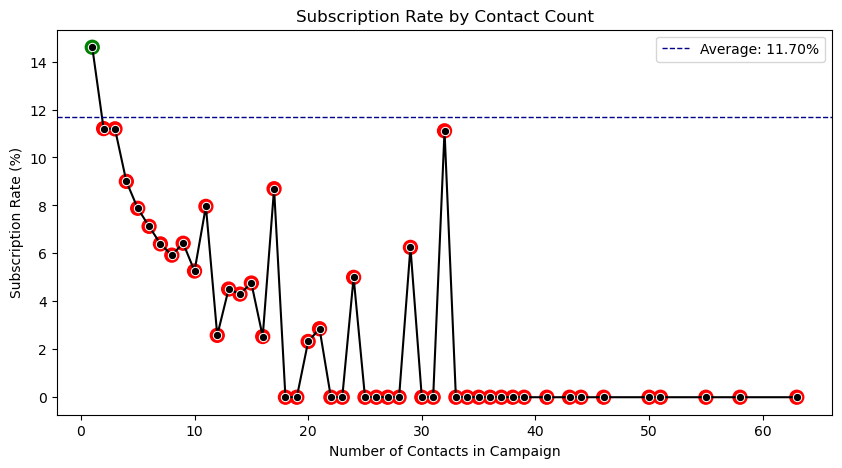

In [175]:
contact_success = eda_df.groupby('campaign')['only_yes'].mean().mul(100).reset_index()

contact_success['color'] = contact_success['only_yes'].apply(lambda x: 'green' if x >= overall_avg else 'red')
plt.figure(figsize=(10,5))
sns.lineplot(data=contact_success, x='campaign', y='only_yes', marker='o', color='black')
plt.scatter(contact_success['campaign'], contact_success['only_yes'], color=contact_success['color'], s=100)
plt.axhline(overall_avg, color='darkblue', linestyle='--', linewidth=1, label=f'Average: {overall_avg:.2f}%')
plt.title('Subscription Rate by Contact Count')
plt.xlabel('Number of Contacts in Campaign')
plt.ylabel('Subscription Rate (%)')
plt.legend()
plt.show()

### Answer: Yes, we can see a strong inverse relationship between contact frequency and subscription rate. Clients contacted only once converted at ~14.8%, while rates drop sharply and consistently as contact count increases, with a few spikes, but these remain below the average subscription rate.

### 4. Are customers with previous successful campaigns significantly more likely to subscribe again?

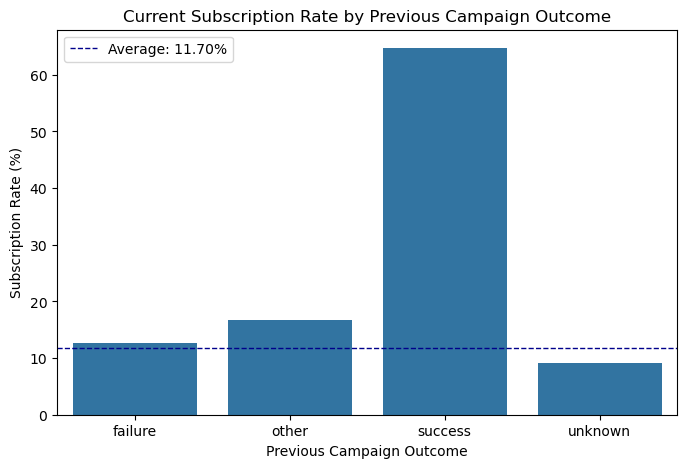

In [176]:
prev_outcome = eda_df.groupby('poutcome')['only_yes'].mean().mul(100).reset_index()

plt.figure(figsize=(8,5))
plt.axhline(overall_avg, color='darkblue', linestyle='--', linewidth=1, label=f'Average: {overall_avg:.2f}%')
sns.barplot(data=prev_outcome, x='poutcome', y='only_yes')
plt.title('Current Subscription Rate by Previous Campaign Outcome')
plt.xlabel('Previous Campaign Outcome')
plt.ylabel('Subscription Rate (%)')
plt.legend()
plt.show()

### Answer: Yes, customers with previous successful campaigns are dramatically more likely to subscribe again.

### 5. Does how we contact the customer matter?

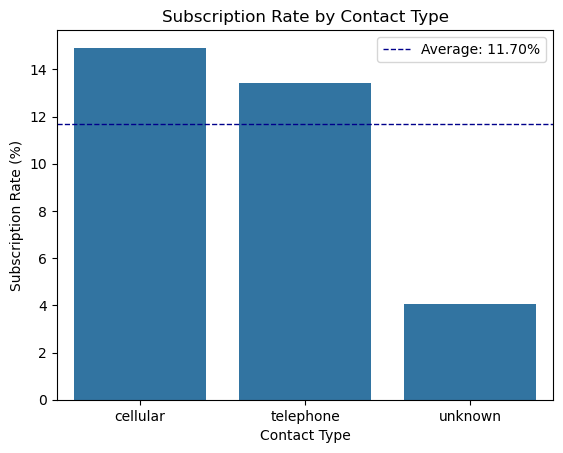

In [177]:
contact_type_success = eda_df.groupby('contact')['only_yes'].mean().mul(100).reset_index()

sns.barplot(data=contact_type_success, x="contact", y="only_yes")
plt.axhline(overall_avg, color='darkblue', linestyle='--', linewidth=1, label=f'Average: {overall_avg:.2f}%')

plt.title('Subscription Rate by Contact Type')
plt.xlabel('Contact Type')
plt.ylabel('Subscription Rate (%)')
plt.legend()
plt.show()


### Answer: No, both contact methods are effective, with the cellular method having a slight, but not significant, advantage.